# LightGBM - Automobile Loan Default Prediction
Fast gradient boosting model with `scale_pos_weight=11.37` and `max_depth=5`.

## 1. Setup

In [1]:
import os
import sys

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Preprocessed Data

In [7]:
import joblib
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
from src.models.decision_tree import train_decision_tree, evaluate_decision_tree, save_decision_tree_model


In [8]:
data_dir = "../data/processed" if os.path.exists("../data/processed") else "data/processed"
X_train_proc = joblib.load(os.path.join(data_dir, "X_train.joblib"))
y_train_proc = joblib.load(os.path.join(data_dir, "y_train.joblib"))
X_test_proc = joblib.load(os.path.join(data_dir, "X_test.joblib"))
y_test_proc = joblib.load(os.path.join(data_dir, "y_test.joblib"))

print("Training samples:", X_train_proc.shape[0])
print("Testing samples: ", X_test_proc.shape[0])


Training samples: 97484
Testing samples:  24372


## 3. LightGBM (Light Gradient Boosting Machine)
A fast gradient boosting model that trains 100 simple trees in sequence, where each new tree learns from the mistakes of previous trees.

In [15]:
from src.models.lightgbm_model import train_lightgbm, evaluate_lightgbm, save_lightgbm_model

### 4.1 Train LightGBM
We train 100 shallow trees (`max_depth=5`) with `scale_pos_weight=11.37` so the model focuses on the 8% defaulters instead of ignoring them.

In [16]:
lgbm_model, lgbm_train_time = train_lightgbm(X_train_proc, y_train_proc)
print(f"LightGBM trained in {lgbm_train_time:.2f} seconds.")

LightGBM trained in 2.50 seconds.


### 4.2 Model Evaluation

In [17]:
lgbm_metrics, lgbm_cm = evaluate_lightgbm(lgbm_model, X_test_proc, y_test_proc)

# Show nicely formatted table
lgbm_results_df = pd.DataFrame([lgbm_metrics])
lgbm_results_df

,accuracy,precision,recall,f1_score,roc_auc,pr_auc,tn,fp,fn,tp
0,0.7125,0.1681,0.6475,0.2668,0.7481,0.2153,16091,6312,694,1275


### 4.3 Confusion Matrix
Check how many defaulters were correctly caught vs missed.

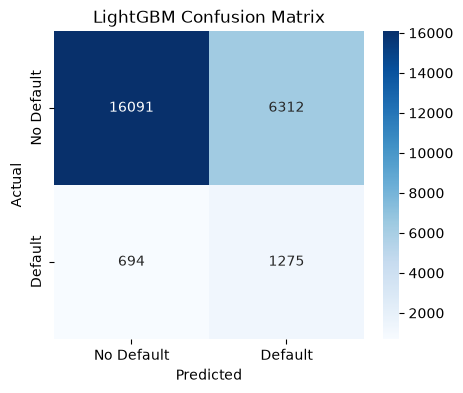

correctly predicted non-defaulters (TN): 16091 | non-defaulters incorrectly predicted as defaulters (FP): 6312
defaulters incorrectly predicted as non-defaulters (FN): 694  | defaulters incorrectly predicted as non-defaulters (TP): 1275


In [23]:
plt.figure(figsize=(5, 4))
sns.heatmap(lgbm_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"correctly predicted non-defaulters (TN): {lgbm_metrics['tn']} | non-defaulters incorrectly predicted as defaulters (FP): {lgbm_metrics['fp']}")
print(f"defaulters incorrectly predicted as non-defaulters (FN): {lgbm_metrics['fn']}  | defaulters incorrectly predicted as non-defaulters (TP): {lgbm_metrics['tp']}")

### 4.4 ROC and Precision-Recall Curves

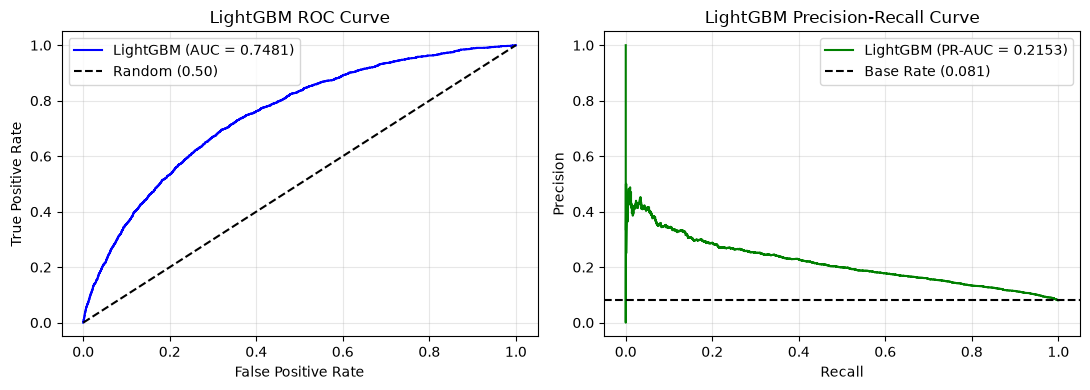

In [19]:
X_test_clean = X_test_proc.rename(columns=lambda c: str(c).replace(":", "_").replace(" ", "_"))
y_proba_lgbm = lgbm_model.predict_proba(X_test_clean)[:, 1]

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test_proc, y_proba_lgbm)
precision_vals_lgbm, recall_vals_lgbm, _ = precision_recall_curve(y_test_proc, y_proba_lgbm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
axes[0].plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC = {lgbm_metrics['roc_auc']})", color="blue")
axes[0].plot([0, 1], [0, 1], "k--", label="Random (0.50)")
axes[0].set_title("LightGBM ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_vals_lgbm, precision_vals_lgbm, label=f"LightGBM (PR-AUC = {lgbm_metrics['pr_auc']})", color="green")
axes[1].axhline(y=y_test_proc.mean(), color="k", linestyle="--", label=f"Base Rate ({y_test_proc.mean():.3f})")
axes[1].set_title("LightGBM Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, "05_lightgbm_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()

### 4.5 Top 10 Feature Importances
The top features that LightGBM uses most often to detect loan defaults.

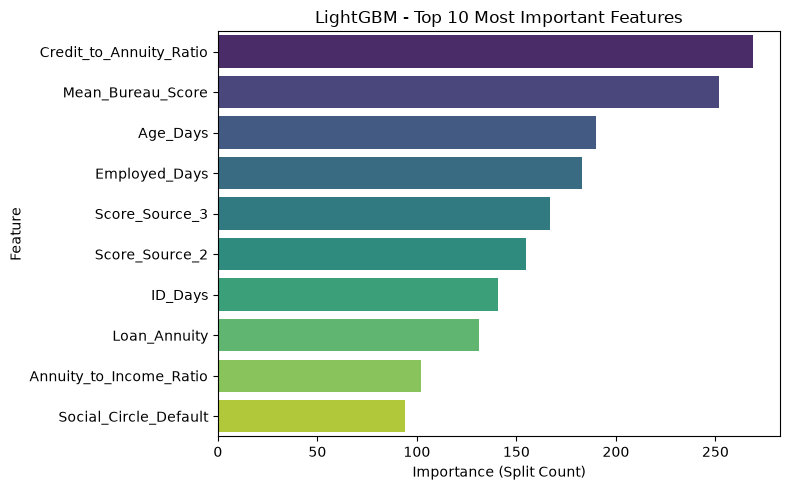

Top 10 Features:
  Credit_to_Annuity_Ratio: 269
  Mean_Bureau_Score: 252
  Age_Days: 190
  Employed_Days: 183
  Score_Source_3: 167
  Score_Source_2: 155
  ID_Days: 141
  Loan_Annuity: 131
  Annuity_to_Income_Ratio: 102
  Social_Circle_Default: 94


In [20]:
feat_importances = pd.Series(
    lgbm_model.feature_importances_,
    index=X_test_clean.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importances.values, y=feat_importances.index, hue=feat_importances.index, palette="viridis", legend=False)
plt.title("LightGBM - Top 10 Most Important Features")
plt.xlabel("Importance (Split Count)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "05_lightgbm_feature_importance.png"), dpi=100, bbox_inches="tight")
plt.show()

print("Top 10 Features:")
for feat, imp in feat_importances.items():
    print(f"  {feat}: {imp}")

### 4.6 Save Model

In [21]:
models_dir = "../models/baseline" if os.path.exists("../models/baseline") else "models/baseline"
save_lightgbm_model(lgbm_model, os.path.join(models_dir, "lightgbm.pkl"))

Model saved to: ../models/baseline\lightgbm.pkl


'../models/baseline\\lightgbm.pkl'

**Finding:** LightGBM achieves test set ROC-AUC 0.748 and PR-AUC 0.215 with a very fast training time of ~2.1 seconds. Setting `scale_pos_weight=11.37` enables the model to catch **64.8% of actual defaulters** (Recall = 0.648), outperforming the Decision Tree baseline (60.5%) while reducing false alarms (Precision 0.168 vs 0.147). The most important predictors of default are `Credit_to_Annuity_Ratio`, `Mean_Bureau_Score`, and `Age_Days`.

**Decision:** ported to `src/models/lightgbm_model.py` as `train_lightgbm()`, `evaluate_lightgbm()`, and `save_lightgbm_model()`, and saved to `models/baseline/lightgbm.pkl` as our gradient boosting baseline.